In [1]:
import sys
sys.path.insert(0, '../../mitsuba3/build/python')

from tqdm import trange

import numpy as np
import matplotlib.pyplot as plt

import drjit as dr
import mitsuba as mi

mi.set_variant('cuda_ad_rgb')

# Constants for training
SUN_PHI = 0
ALBEDO = 0.5
MIN_ETA = dr.deg2rad(2)
MAX_ETA = dr.deg2rad(88)

## Setup optimization

In [2]:
""" Function that we want to fit"""
def get_lum(sky_rad, sky_params, cos_theta, gamma):
    cos_gamma = dr.cos(gamma)
    cos_gamma_2 = cos_gamma * cos_gamma

    res = dr.copy(sky_rad)
    for channel_idx in range(3):
        c1 = 1 + sky_params[channel_idx * 9 + 0] * dr.exp(sky_params[channel_idx * 9 + 1] / (cos_theta + 0.01))
        chi = (1 + cos_gamma_2) / ((1 + sky_params[channel_idx * 9 + 8]**2 - 2 * sky_params[channel_idx * 9 + 8] * cos_gamma)**1.5)
        c2 = sky_params[channel_idx * 9 + 2] + sky_params[channel_idx * 9 + 3] * dr.exp(sky_params[channel_idx * 9 + 4] * gamma) + \
                sky_params[channel_idx * 9 + 5] * cos_gamma_2 + sky_params[channel_idx * 9 + 6] * chi + sky_params[channel_idx * 9 + 7] * dr.safe_sqrt(cos_theta)

        res[channel_idx] *= c1 * c2
    
    return mi.luminance(res) * mi.MI_CIE_Y_NORMALIZATION & (cos_theta > 0)

In [3]:
""" Computes the normalization factor for the luminance function above """

@dr.syntax
def integrate_luminance(sun_dir, sky_rad, sky_params, cos_thetas, phis, quad_weights):

    i = mi.UInt32(0)
    total_lum = mi.Float(0)
    while i < dr.width(cos_thetas):
        # Gather inputs
        ct = dr.gather(mi.Float, cos_thetas, i)
        phi = dr.gather(mi.Float, phis, i)
        weight = dr.gather(mi.Float, quad_weights, i)

        # Compute direction
        st = dr.safe_sqrt(1 - ct**2)
        sp, cp = dr.sincos(phi)
        dir = mi.Vector3f(st * cp, st * sp, ct)
        gamma = dr.unit_angle(dir, sun_dir)

        res = get_lum(sky_rad, sky_params, ct, gamma)
        total_lum += weight * res
        i += 1
    
    return total_lum

def compute_norm_factor(sun_dir, sky_rad, sky_params):
    quad_points, quad_weights = mi.quad.gauss_legendre(200)
    cos_theta = quad_points * 0.5 + 0.5
    phi = dr.pi * (quad_points + 1)
    cos_theta, phi = dr.meshgrid(cos_theta, phi)
    phi_weights, cos_theta_weights = dr.meshgrid(quad_weights, quad_weights)
    weights = 0.5 * dr.pi * cos_theta_weights * phi_weights

    return dr.rcp(integrate_luminance(sun_dir, sky_rad, sky_params, cos_theta, phi, weights))

In [4]:
from vizsky_contrib import interpolate_dataset

def init_optimization_vars(sky_rad_dataset, sky_params_dataset, turb_res=10, sun_eta_res=30):

    # Define grid of turbidity and sun elevation angles
    turbs = dr.linspace(mi.Float, 1.0, 10.0, turb_res)
    sun_etas = dr.linspace(mi.Float, MIN_ETA, MAX_ETA, sun_eta_res)
    turbs, sun_etas = dr.meshgrid(turbs, sun_etas)
    tex_pos = mi.Point2f((turbs - 1) / (10 - 1), (sun_etas - MIN_ETA) / (MAX_ETA - MIN_ETA))

    # Precompute sky radiance and parameters for each (turbidity, sun_eta) pair
    sky_rad = interpolate_dataset(sky_rad_dataset, ALBEDO, turbs, sun_etas)
    sky_params = interpolate_dataset(sky_params_dataset, ALBEDO, turbs, sun_etas)

    sky_rad = mi.Color3f(sky_rad)

    # Compute sun direction for each (turbidity, sun_eta) pair
    sun_thetas = dr.pi / 2 - sun_etas
    st, ct = dr.sincos(sun_thetas)
    sp, cp = dr.sincos(SUN_PHI)
    sun_dir = mi.Vector3f(st * cp, st * sp, ct)

    dr.eval(sky_rad, sky_params, sun_dir, tex_pos)

    # Compute normalization factor for each (turbidity, sun_eta) pair
    norm_factor = compute_norm_factor(sun_dir, sky_rad, sky_params)
    dr.eval(norm_factor)


    return sky_rad, sky_params, sun_dir, tex_pos, norm_factor

In [5]:
from vizsky_contrib import load_tensors

TRAINING_TURB_RES = 31
TRAINING_SUN_ETA_RES = 93

sky_rad_dataset, sky_params_dataset = load_tensors('../../mitsuba3/resources/data/sunsky/output/sunsky_datasets.bin')

sky_rad, sky_params, sun_dir, tex_pos, norm_factor = init_optimization_vars(
    sky_rad_dataset, sky_params_dataset,
    turb_res=TRAINING_TURB_RES, sun_eta_res=TRAINING_SUN_ETA_RES
)


Loading tensor data from "../../mitsuba3/resources/data/sunsky/output/sunsky_datasets.bin" .. (540.0 KiB, 7 fields)


### Vizalize a few luminance maps to check all is ok

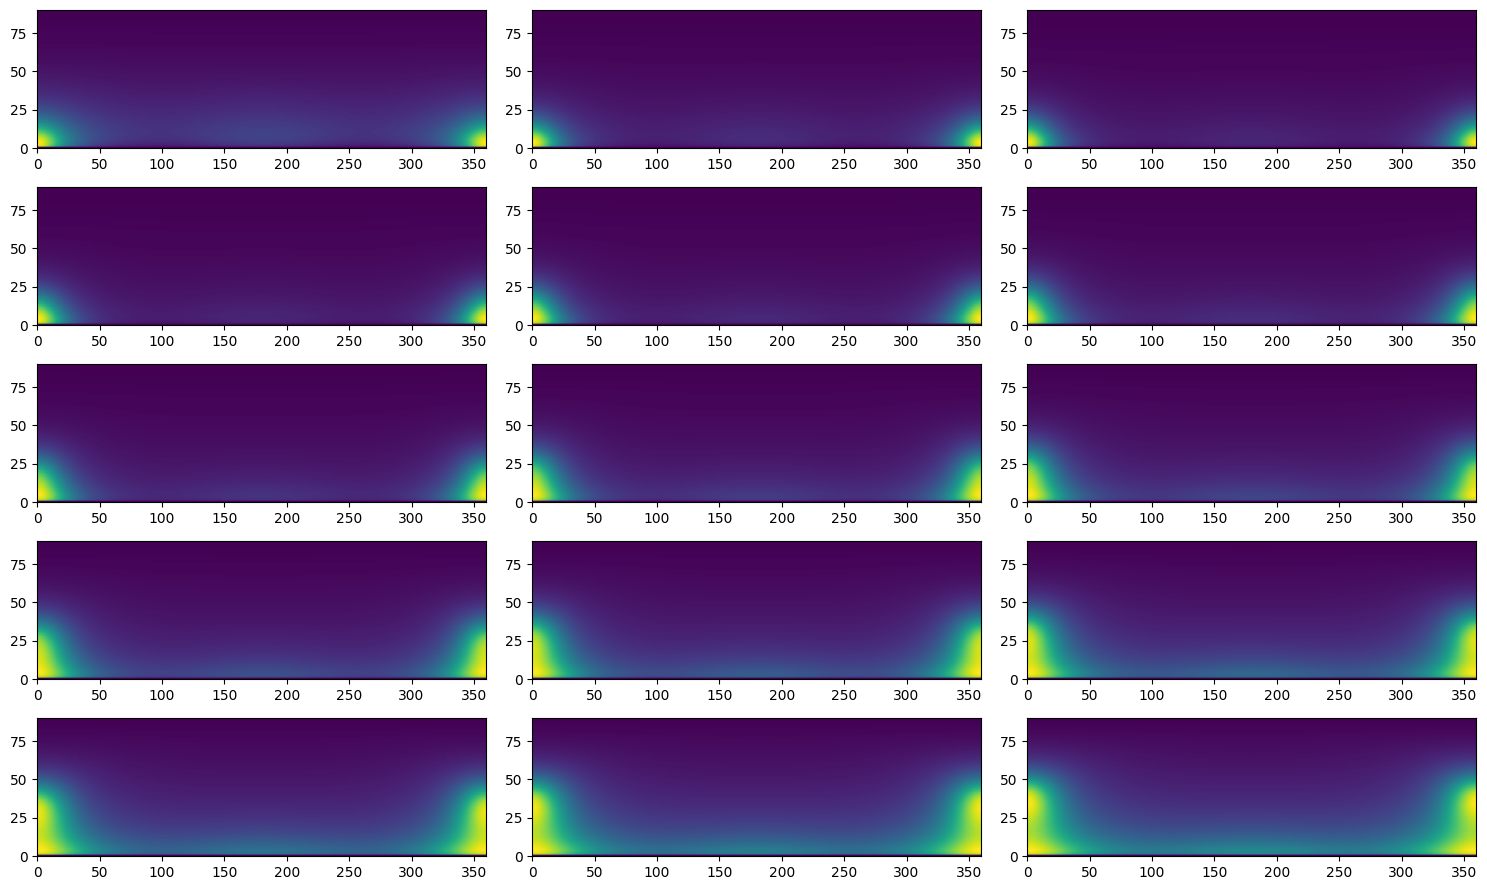

In [6]:
def viz_sky_map(sun_dir, sky_rad, sky_params, norm_factor, idx):

    sun_dir = dr.gather(mi.Vector3f, sun_dir, idx)
    sky_rad = dr.gather(mi.Color3f, sky_rad, idx)
    sky_params = dr.gather(mi.ArrayXf, sky_params, idx, shape=(3 * 9, 1))
    norm_factor = dr.gather(mi.Float, norm_factor, idx)

    viz_res = (400, 100)
    phi, thetas = dr.meshgrid(
        dr.linspace(mi.Float, 0, 2 * dr.pi, viz_res[0]),
        dr.linspace(mi.Float, 0, dr.pi / 2 + 0.001 * dr.pi, viz_res[1])
    )
    st, ct = dr.sincos(thetas)
    sp, cp = dr.sincos(phi)
    wi = mi.Vector3f(st * cp, st * sp, ct)

    gamma = dr.unit_angle(wi, sun_dir)

    pdf = get_lum(sky_rad, sky_params, ct, gamma) * st * norm_factor
    return mi.TensorXf(pdf, shape=viz_res[::-1])


fig, axs = plt.subplots(5, 3, figsize=(15, 9))
axs = axs.flatten()
for i in range(5*3):
    pdf = viz_sky_map(sun_dir, sky_rad, sky_params, norm_factor, TRAINING_SUN_ETA_RES * i + 15)
    axs[i].imshow(pdf, origin='upper', 
                extent=[0, 360, 0, 90], aspect='auto')

fig.tight_layout()
plt.show()

In [7]:
def warp_u(weight, u):
    return weight * u / dr.sqrt(1 + u*u * (weight*weight -1))

def warp_1_pdf(weight, uv):
    """ 
    First warp: maps samples in (cos(theta), phi) space lower on the horizon
    """
    new_u = warp_u(weight, uv.x)
    inverse_jacobian = dr.rcp(weight * dr.power(1 + new_u*new_u*(1/(weight**2) - 1), 1.5))
    return mi.Point2f(new_u, uv.y), inverse_jacobian

def warp_2_pdf(weights, uv, eval=False):
    """ 
    Second warp: maps samples in (cos(theta), phi) space towards the sun direction with a gaussian warp
    """
    mean = mi.Point2f(weights[0], SUN_PHI)
    sigma = mi.Point2f(weights[1], weights[2])

    # TODO: implement the actual warp
    if dr.hint(eval, mode='scalar'):
        # CDF(0, 0)
        cdf_a = 0.5 * (1 + dr.inv_sqrt_two * dr.erf(-mean / sigma))
        # CDF(1, 2pi)
        cdf_b = 0.5 * (1 + dr.inv_sqrt_two * dr.erf((mi.ScalarPoint2f(1.0, dr.two_pi) - mean) / sigma))

        trunc_constant = (cdf_b.x - cdf_a.x) * (cdf_b.y - cdf_a.y)
        volume = trunc_constant * (sigma.x * sigma.y)

        return 0, mi.warp.square_to_std_normal_pdf((uv - mean) / sigma) / volume, trunc_constant
    else:
        volume = (sigma.x * sigma.y)

        return 0, mi.warp.square_to_std_normal_pdf((uv - mean) / sigma) / volume, 1.0


def approximate_pdf(weights, uv, eval):
    """ Function we will use to approximate the PDF
        arguments:
            weights: list of weights for the warp
            uv: (cos_theta, phi) coordinates of the point where to evaluate the PDF
        returns:
            approximated PDF value at the given point
    """
    # TODO & (0 <= uv.y) & (uv.y <= dr.two_pi)
    uv1, pdf1 = warp_1_pdf(weights[1], uv)
    todo, pdf2, trunc_const = warp_2_pdf(weights[2:], uv, eval)

    valid_range = (0 <= uv.x) & (uv.x <= 1)
    if dr.hint(eval, mode='scalar'):
        return (dr.inv_pi * pdf1 + weights[0] * pdf2) / (1 + trunc_const * weights[0]) & valid_range
    else:
        return (dr.inv_pi * pdf1 + weights[0] * pdf2) & valid_range

In [8]:
def init_optimised_weights(turb_res, sun_eta_res):
    rng = dr.rng(42)
    horizon_warp = rng.normal(mi.TensorXf, shape=(sun_eta_res, turb_res, 1), loc=0.8, scale=0.01)
    turbs, sun_elevation = dr.meshgrid(
        dr.linspace(mi.Float, 1, 10, turb_res),
        dr.linspace(mi.Float, MIN_ETA, MAX_ETA, sun_eta_res),
        indexing='xy'
    )
    cos_sun_elevation = mi.TensorXf(dr.cos(dr.pi/2 - sun_elevation), shape=(sun_eta_res, turb_res, 1))
    
    weight = rng.normal(mi.TensorXf, shape=(sun_eta_res, turb_res, 1), loc=0.5, scale=0.2)
    sun_sigma = dr.full(mi.TensorXf, dr.pi/5, shape=(sun_eta_res, turb_res, 2))
    return dr.concat((weight, horizon_warp, cos_sun_elevation, sun_sigma), axis=2)

def clamp_channels(weights, channel_idx, min_val=-dr.inf, max_val=dr.inf):
    """ Clamps the weights to avoid numerical issues during optimization """
    idx = dr.arange(mi.UInt32, dr.prod(weights.shape[:-1])) * weights.shape[-1] + channel_idx
    channel_weights = dr.gather(mi.Float, weights.array, idx)
    clamped_weights = dr.clip(channel_weights, min_val, max_val)
    dr.scatter(weights.array, clamped_weights, idx)

    return weights


In [9]:
@dr.syntax
def compute_loss_per_gridpoint(tex_weights, tex_pos, sky_rad, sky_params, norm_factor, sun_dir, wi, nb_wi):
    weights = tex_weights.eval(tex_pos)

    ray_idx = mi.UInt32(0)
    total_loss = mi.Float(0)
    while dr.hint(ray_idx < nb_wi, max_iterations=-1):
        direction = dr.gather(mi.Vector3f, wi, ray_idx)
        cos_theta = mi.Frame3f.cos_theta(direction)
        phi = dr.atan2(direction.y, direction.x)
        gamma = dr.unit_angle(direction, sun_dir)

        target_pdf = get_lum(sky_rad, sky_params, cos_theta, gamma) * norm_factor
        approx_pdf = approximate_pdf(weights, mi.Point2f(cos_theta, phi), False)
        
        total_loss += (approx_pdf - target_pdf) ** 2

        ray_idx += 1        

    return total_loss / nb_wi

@dr.syntax
def compute_accuracy_per_gridpoint(tex_weights, tex_pos, sky_rad, sky_params, norm_factor, sun_dir, wi, nb_wi):
    weights = tex_weights.eval(tex_pos)

    ray_idx = mi.UInt32(0)
    total_accuracy = mi.Float(0)
    while dr.hint(ray_idx < nb_wi, max_iterations=-1):
        direction = dr.gather(mi.Vector3f, wi, ray_idx)
        cos_theta = mi.Frame3f.cos_theta(direction)
        phi = dr.atan2(direction.y, direction.x)
        gamma = dr.unit_angle(direction, sun_dir)

        target_pdf = get_lum(sky_rad, sky_params, cos_theta, gamma) * norm_factor
        approx_pdf = approximate_pdf(weights, mi.Point2f(cos_theta, phi), False)

        total_accuracy += dr.abs(approx_pdf - target_pdf) / dr.maximum(target_pdf, 1e-5)

        ray_idx += 1        

    return total_accuracy / nb_wi

@dr.freeze
def compute_loss(tex_weights, tex_pos, sky_rad, sky_params, norm_factor, sun_dir, wi, nb_wi):
    # MSE for each luminance map 
    loss = compute_loss_per_gridpoint(
        tex_weights, tex_pos, sky_rad, sky_params, norm_factor, sun_dir, wi, nb_wi
    )

    # keep the mean arround the sun elevation
    weights = tex_weights.eval(tex_pos)
    gaussian_elevation = weights[2]
    real_sun_elevation = dr.cos(dr.pi/2 - tex_pos.y * (MAX_ETA - MIN_ETA) + MIN_ETA)
    err = real_sun_elevation - gaussian_elevation
    regularizer = 0.00005 * (err ** 2)

    # keep a downward warp towards the horizon
    diff = 1 - weights[1]
    regularizer += 0.5 * dr.select(
        diff > 0, 0, diff**2
    )


    dr.backward(loss + regularizer)

    return dr.mean(loss)

Optimizing:   0%|          | 0/7000 [00:00<?, ?it/s]

Optimizing: 100%|██████████| 7000/7000 [02:07<00:00, 55.10it/s, Loss: [0.0329478]]


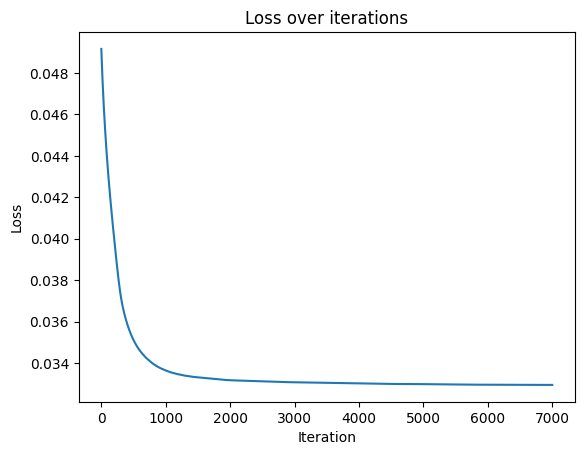

In [10]:
## Generate initial weights
turb_res = 10
sun_eta_res = 30
opt_key = "weights"

weights = init_optimised_weights(turb_res, sun_eta_res)
tex_weights = mi.Texture2f(weights, 
                           wrap_mode=dr.WrapMode.Clamp,
                           migrate=False)

opt = mi.ad.Adam(lr=0.001)
opt[opt_key] = weights

## Generate rays to evaluate luminance map
lum_map_height = 150
phis, thetas = dr.meshgrid(
    dr.linspace(mi.Float, 0, 2 * dr.pi, 2 * lum_map_height),
    dr.linspace(mi.Float, 0, dr.pi / 2 + 0.001 * dr.pi, lum_map_height)
)
st, ct = dr.sincos(thetas)
sp, cp = dr.sincos(phis)
wi = mi.Vector3f(st * cp, st * sp, ct)
dr.eval(wi)

def update_and_clamp_weights(optimizer, tex_weights):
    tensor = clamp_channels(optimizer[opt_key], 0, min_val=0)
    tensor = clamp_channels(tensor, 1, min_val=dr.epsilon(mi.Float))
    tensor = clamp_channels(tensor, 2, min_val=0)
    #tensor = clamp_channels(tensor, 4, min_val=0.01, max_val=dr.pi/4)
    optimizer[opt_key] = tensor
    tex_weights.set_tensor(optimizer[opt_key])

## Optimize
losses = []
iterations = trange(7000, desc="Optimizing")
for it in iterations:

    update_and_clamp_weights(opt, tex_weights)

    loss = compute_loss(tex_weights, tex_pos, sky_rad, sky_params, norm_factor, sun_dir, wi, dr.width(wi))

    opt.step()

    if it % 5 == 0:
        iterations.set_postfix_str(f"Loss: {loss}")

    losses.append(loss)

update_and_clamp_weights(opt, tex_weights)
optimal_weights = opt[opt_key]

plt.close()
cutoff = 0
losses_to_plot = losses[cutoff:]
plt.plot(np.arange(len(losses_to_plot)) + cutoff, losses_to_plot)
plt.title('Loss over iterations')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

## Find the worse fitter

In [13]:
def plot_weights_and_losses(fig, tex_weights, losses_per_point, rel_err_per_point):

    def show_im(im, ax, title, xlabel='', ylabel=''):
        im = ax.imshow(im, origin='lower', 
                    extent=[1.0, 10.0, 2.0, 88.0], aspect='auto')
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        fig.colorbar(im, ax=ax)


    weights = tex_weights.tensor()
    axs = fig.subplots(4, 2, sharex=True, sharey=True)
    show_im(losses_per_point, axs[0,0], 'MSE per grid point', ylabel='Sun Elevation (degrees)')
    show_im(rel_err_per_point, axs[0,1], 'MRE per grid point')

    show_im(weights[..., 0], axs[1,0], 'Pick Gaussian weight', ylabel='Sun Elevation (degrees)')
    show_im(weights[..., 1], axs[1,1], 'Horizon warp weight')
    show_im(weights[..., 3], axs[2,0], 'Sun elevation sigma',ylabel='Sun Elevation (degrees)', xlabel='Turbidity')
    show_im(weights[..., 4], axs[2,1], 'Sun azimuth sigma', xlabel='Turbidity')
    show_im(weights[..., 2], axs[3,0], 'Cosine of Gaussian mean (sun elevation)', ylabel='Sun Elevation (degrees)', xlabel='Turbidity')

    fig.delaxes(axs[3,1])

    fig.suptitle('Losses and weights per gridpoint', fontsize='x-large')

def plot_pdf(fig, tex_weights, chosen_point):
    axs = fig.subplots(1, 2, sharey=True)

    chosen_tex_pos = dr.gather(mi.Point2f, tex_pos, chosen_point)
    chosen_weights = tex_weights.eval(chosen_tex_pos)
    #chosen_weights = [0.3, *chosen_weights[1:]]
    dr.print(chosen_weights)

    # Target pdf
    target_pdf = viz_sky_map(sun_dir, sky_rad, sky_params, norm_factor, chosen_point)

    # Approximate pdf
    cos_theta = mi.Frame3f.cos_theta(wi)
    phi = dr.atan2(wi.y, wi.x)

    approx_pdf = approximate_pdf(chosen_weights, mi.Point2f(cos_theta, phi), True)
    approx_pdf = mi.TensorXf(approx_pdf, shape=(lum_map_height, 2 * lum_map_height))

    vmin = dr.minimum(dr.min(target_pdf), dr.min(approx_pdf))
    vmax = dr.maximum(dr.max(target_pdf), dr.max(approx_pdf))
    vmin = None
    vmax = None

    axs[0].set_title('Target sky pdf')
    axs[0].set_xlabel('Azimuth (degrees)')
    axs[0].set_ylabel('Elevation (degrees)')
    axs[0].imshow(target_pdf, origin='upper', 
                extent=[0, 360, 0, 90], aspect='auto', vmin=vmin, vmax=vmax)

    axs[1].set_title('Approximate sky pdf')
    axs[1].set_xlabel('Azimuth (degrees)')
    im1 = axs[1].imshow(approx_pdf, origin='upper', 
                extent=[0, 360, 0, 90], aspect='auto', vmin=vmin, vmax=vmax)

    point = (chosen_tex_pos.x * 9 + 1, chosen_tex_pos.y * (MAX_ETA - MIN_ETA) + MIN_ETA)

    #fig.colorbar(im1, ax=axs[1])
    fig.suptitle(f'Chosen pdf plot: {point[0]} turbidity and {dr.rad2deg(point[1])}° sun elevation', fontsize='x-large')

[
  [0.0701328],
  [0.957115],
  [1.00656],
  [0.0178708],
  [2.6764]
]
[
  [0.268061],
  [0.795049],
  [0.225747],
  [0.170607],
  [0.219684]
]


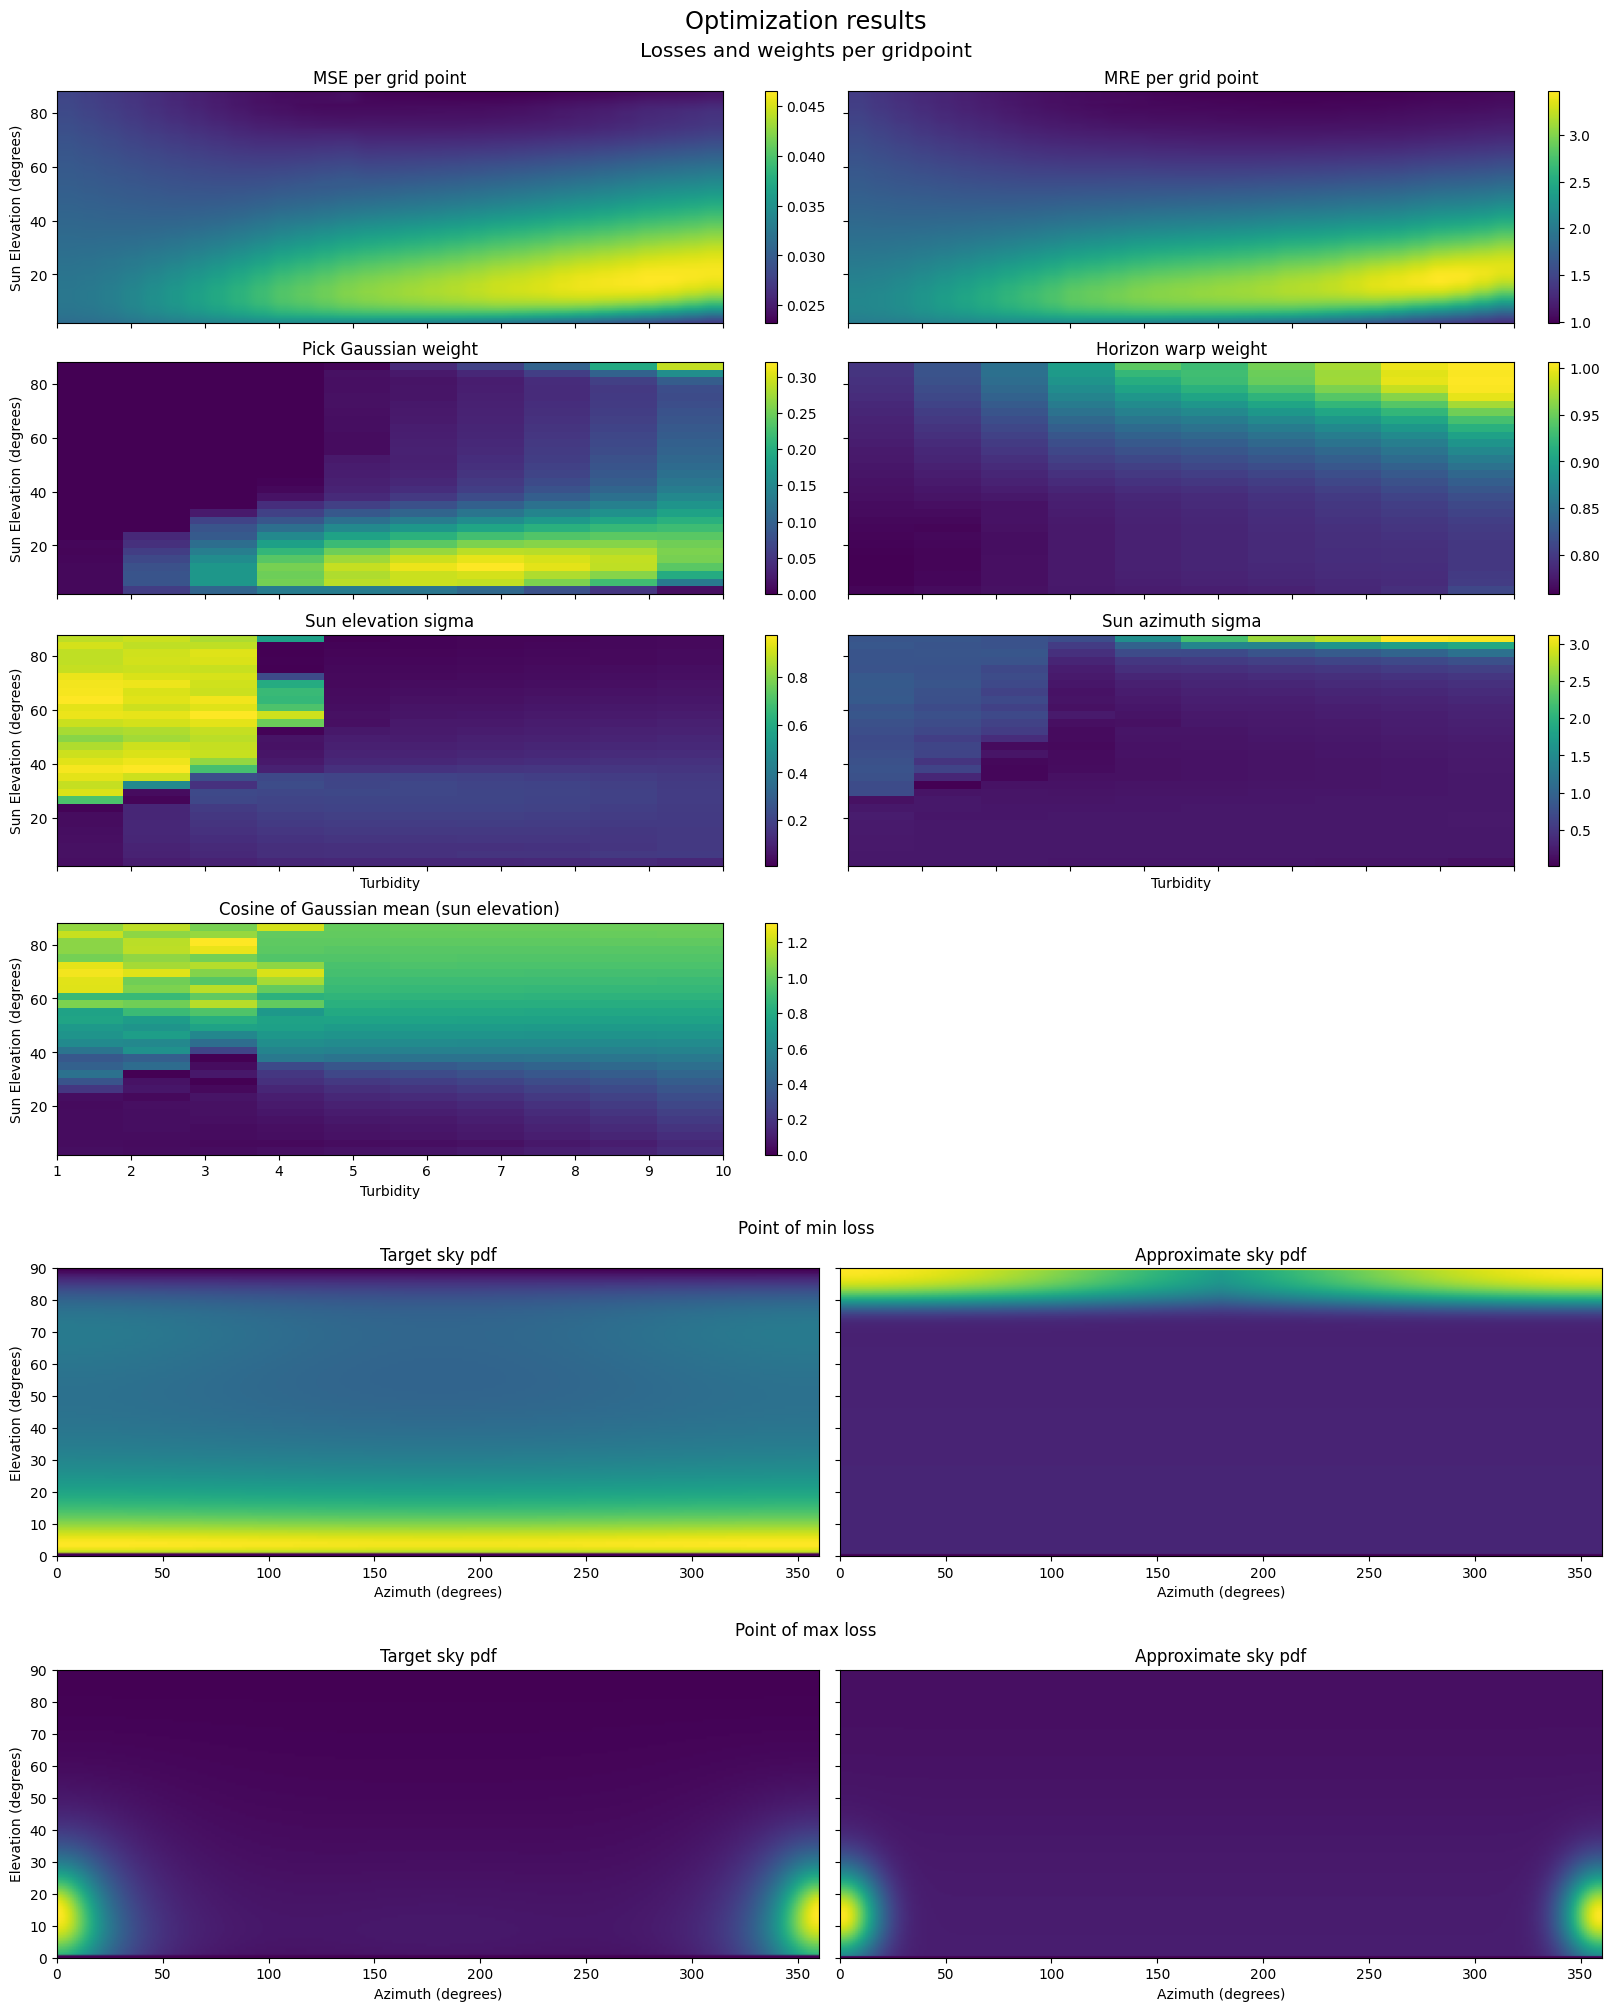

In [14]:
losses_per_point = compute_loss_per_gridpoint(
    tex_weights, tex_pos, sky_rad, sky_params, norm_factor, sun_dir, wi, dr.width(wi)
)
rel_err_per_point = compute_accuracy_per_gridpoint(
    tex_weights, tex_pos, sky_rad, sky_params, norm_factor, sun_dir, wi, dr.width(wi)
)
losses_per_point = mi.TensorXf(losses_per_point, shape=(TRAINING_SUN_ETA_RES, TRAINING_TURB_RES))
rel_err_per_point = mi.TensorXf(rel_err_per_point, shape=(TRAINING_SUN_ETA_RES, TRAINING_TURB_RES))


chosen_points = []
if True:
    chosen_points.append((np.argmin(losses_per_point), "Point of min loss"))
    chosen_points.append((np.argmax(losses_per_point), "Point of max loss"))
    #chosen_point = np.argmax(rel_err_per_point)
else:
    chosen_turb = 2
    chosen_sun_eta = dr.deg2rad(50)
    chosen_turb = ((chosen_turb - 1) / 9) * (TRAINING_TURB_RES - 1)
    chosen_sun_eta = ((chosen_sun_eta - MIN_ETA) / (MAX_ETA - MIN_ETA)) * (TRAINING_SUN_ETA_RES - 1)
    chosen_point = dr.round(chosen_sun_eta) * TRAINING_TURB_RES + dr.round(chosen_turb)
    chosen_points.append(chosen_point)

fig = plt.figure(layout='constrained', figsize=(16, 20))
subfigs = fig.subfigures(len(chosen_points) + 1, 1, wspace=0.07, height_ratios=[3]+[1]*len(chosen_points))

### FIRST PLOT THE WEIGHTS AND LOSSES PER GRIDPOINT
plot_weights_and_losses(subfigs[0], tex_weights, losses_per_point, rel_err_per_point)

### SECOND PLOT THE SKY PDFS FOR A CHOSEN GRIDPOINT
for i, (chosen_point, plot_title) in enumerate(chosen_points):
    plot_pdf(subfigs[i+1], tex_weights, chosen_point)
    subfigs[i+1].suptitle(plot_title, fontsize='large')
fig.suptitle('Optimization results', fontsize='xx-large')
plt.show()